# **Bluestock_MF_Capstone_Project**
### **Phase 6: Advanced Analytics**

---
* **Prepared By:** Aalok Kumar Singh
* **Date:** June 7, 2026
* **Contact:** aalokkrsingh27@gmail.com
* **Role:** Data Analytics Intern
---


### **Task 1 Code: Compute Historical VaR & CVaR**

In [ ]:
# Import libraries
import pandas as pd 
import numpy as np

In [29]:
# 1. Load NAV dataset
nav_df = pd.read_csv("../data/processed/clean_nav.csv")

In [30]:
nav_df

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
...,...,...,...
45995,149324,2026-05-25,292.4810
45996,149324,2026-05-26,291.2707
45997,149324,2026-05-27,288.8007
45998,149324,2026-05-28,280.6873


In [31]:
# 2. Sort by fund and date to ensure chronological order
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(by=['amfi_code', 'date'])

In [32]:
# 3. Calculating the daily percentage return for each fund
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

In [33]:
# Drop the first day (NaN) for each fund
nav_df = returns_df = nav_df.dropna(subset=['daily_return']).copy()

In [35]:
# 4. Define the VaR and CVaR function
def calc_risk_metrics(group):
    # 5th percentile (95% confidence)
    var_95 = np.percentile(group['daily_return'], 5) 
    
    # Mean of returns that are worse than or equal to VaR
    cvar_95 = group[group['daily_return'] <= var_95]['daily_return'].mean() 
    
    # Multiplpy it with 100 so to make it in percentage 
    return pd.Series({
        'Var_95_%': round(var_95 * 100, 2),
        "CVar_95_%": round(cvar_95 * 100, 2)
    })


In [37]:
# 5. Apply the function to group by fund
risk_report = returns_df.groupby('amfi_code').apply(calc_risk_metrics).reset_index()

In [41]:
# 6. Save the file 
output_path = '../reports/var_cvar_report.csv' 
risk_report.to_csv(output_path, index=False)

### **Task 2: The Rolling 90-Day Sharpe Ratio**

In [42]:
# Import libraries 
import matplotlib.pyplot as plt 

In [ ]:
# 1. Selecting the top 5 funds 
top_5_amfi = returns_df['amfi_code'].value_counts().head(5).index.tolist()
top_5_df = returns_df[returns_df['amfi_code'].isin(top_5_amfi)].copy()


In [ ]:
# 2. Pivot the data so each column is a fund and rows are dates
pivot_returns = top_5_df.pivot(index='date', columns='amfi_code', values='daily_return')

In [49]:
# 3. Calculate the Rolling 90-Day Sharpe Ratio
trading_days = 252
rolling_window = 90

In [50]:
# Formula: (Rolling Mean / Rolling Std Dev) * sqrt(252)
rolling_mean = pivot_returns.rolling(window=rolling_window).mean()
rolling_std = pivot_returns.rolling(window=rolling_window).std()
rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(trading_days)

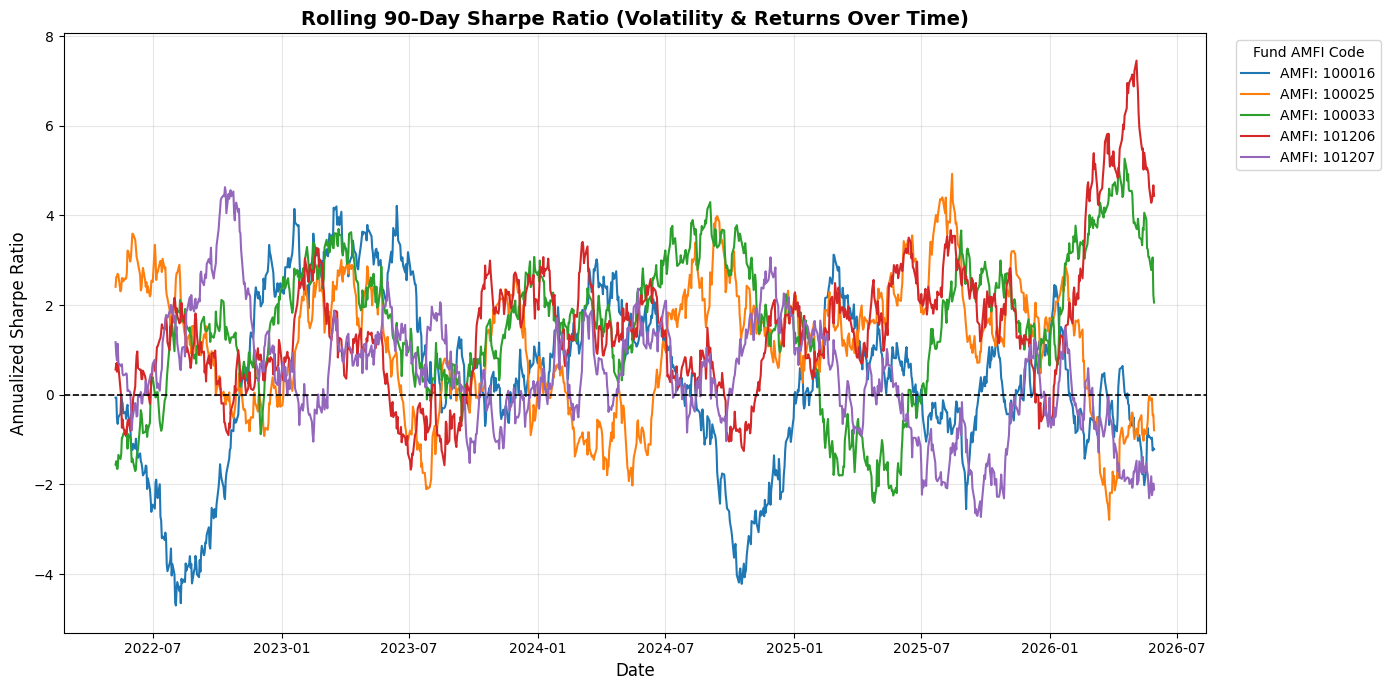

In [56]:
# 4. Plot the data
plt.figure(figsize=(14, 7))

# Loop through our 5 columns and plot each line
for fund in rolling_sharpe.columns:
    plt.plot(rolling_sharpe.index, rolling_sharpe[fund], label=f'AMFI: {fund}', linewidth=1.5)

# 5. Format the chart to look professional
plt.title('Rolling 90-Day Sharpe Ratio (Volatility & Returns Over Time)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Annualized Sharpe Ratio', fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1.2) # Baseline at 0
plt.legend(title="Fund AMFI Code", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 6. Save the plot
chart_path = '../reports/rolling_sharpe_chart.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')

plt.show()


### **Task 3: The Cohort**

In [57]:
# Import libraries 
import pandas as pd

In [62]:
# 1. Load the dataset 
tx_df = pd.read_csv('../data/processed/clean_transactions.csv')

In [64]:
# 2. Fix Formatting (Dates and Capitalization)
tx_df['transaction_date'] = pd.to_datetime(tx_df['transaction_date'])
tx_df['transaction_type'] = tx_df['transaction_type'].str.upper()

In [65]:
# 3. Determine the "Cohort" (First transaction year for each investor)
first_tx = tx_df.groupby('investor_id')['transaction_date'].min().reset_index()
first_tx['cohort_year'] = first_tx['transaction_date'].dt.year

In [66]:
# 4. Merge the cohort year back into the main transaction dataframe
tx_df = pd.merge(tx_df, first_tx[['investor_id', 'cohort_year']], on='investor_id', how='left')

In [ ]:
# Validating the Data Frame after merge
tx_df

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32773,INV003340,2025-05-30,101207,LUMPSUM,168029,Madhya Pradesh,Indore,T30,26-35,Male,22.5,Net Banking,Verified,2024
32774,INV001838,2025-05-30,119093,SIP,2175,Uttar Pradesh,Kanpur,B30,46-55,Male,27.6,Mandate,Verified,2024
32775,INV000074,2025-05-30,120504,SIP,25998,Rajasthan,Jaipur,T30,26-35,Female,8.4,UPI,Verified,2024
32776,INV002929,2025-05-30,148568,SIP,459,West Bengal,Kolkata,T30,26-35,Male,13.0,Mandate,Verified,2024


In [73]:
# 5. Filter for SIPs to calculate the Average SIP Amount
sip_df = tx_df[tx_df['transaction_type'] == 'SIP']
avg_sip_by_cohort = sip_df.groupby('cohort_year')['amount_inr'].mean().round(2).reset_index(name='avg_sip_amount')

In [75]:
# 6. Calculate Total Invested by Cohort (All transaction types)
total_invested_by_cohort = tx_df.groupby('cohort_year')['amount_inr'].sum().reset_index(name='total_invested')

In [80]:
# 6. Calculate Total Invested by Cohort (All transaction types)
total_invested_by_cohort = tx_df.groupby('cohort_year')['amount_inr'].sum().reset_index(name='total_invested')

In [81]:
# 7. Find Fund Preference (Most popular fund by transaction count in each cohort)
fund_pref = tx_df.groupby(['cohort_year', 'amfi_code']).size().reset_index(name='tx_count')
top_fund_by_cohort = fund_pref.sort_values(['cohort_year', 'tx_count'], ascending=[True, False]).drop_duplicates('cohort_year')
top_fund_by_cohort = top_fund_by_cohort.rename(columns={'amfi_code': 'top_fund_amfi'})

In [82]:
# 8. Bring it all together into one clean summary table
cohort_analysis = pd.merge(avg_sip_by_cohort, total_invested_by_cohort, on='cohort_year')
cohort_analysis = pd.merge(cohort_analysis, top_fund_by_cohort[['cohort_year', 'top_fund_amfi']], on='cohort_year')

In [84]:
# 9. Save the final deliverable
output_path = '../reports/cohort_analysis.csv'
cohort_analysis.to_csv(output_path, index=False)
cohort_analysis.head()

,cohort_year,avg_sip_amount,total_invested,top_fund_amfi
0,2024,10996.89,3491125187,148568
1,2025,13505.21,30455243,119599


##### **Key Insights**
- **Higher Ticket Size in 2025:** The 2025 cohort has a higher average SIP ticket size (~₹13.5k) compared to the 2024 cohort (~11k).\
- **Asset Maturity:** The 2024 cohort contributes to over 99% of the total invested value, showing the compounding effect and maturity of older investors.\
- **Preference Rotation:** There is a clear shift in investment preference, moving from AMFI 148568 (2024) to AMFI 119599 (2025).

### **Task 4: SIP continuation analysis**

In [85]:
# 1. Filter for only SIP transactions
sip_tx = tx_df[tx_df['transaction_type'] == 'SIP'].copy()

In [88]:
# 2. Sort to ensure dates are chronological for each investor
sip_tx = sip_tx.sort_values(['investor_id', 'transaction_date'])
sip_tx

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11571,INV004998,2024-06-30,120507,SIP,15490,Gujarat,Ahmedabad,T30,36-45,Male,24.2,Mandate,Verified,2024
23077,INV004998,2024-12-29,102885,SIP,17075,Gujarat,Ahmedabad,T30,36-45,Male,24.2,Cheque,Verified,2024
25752,INV004998,2025-02-09,102885,SIP,8707,Gujarat,Ahmedabad,T30,36-45,Male,24.2,Mandate,Verified,2024
9305,INV004999,2024-05-26,100016,SIP,6290,Telangana,Hyderabad,T30,26-35,Male,24.8,Net Banking,Verified,2024


In [87]:
# 3. Find investors who have a solid history (6 or more SIPs)
sip_counts = sip_tx.groupby('investor_id').size()
valid_investors = sip_counts[sip_counts >= 6].index

In [89]:
# Filter the dataframe to only keep these experienced investors
filtered_sips = sip_tx[sip_tx['investor_id'].isin(valid_investors)].copy()

In [90]:
# 4. Calculate the exact days between transactions
# We shift the date column down by 1 row within each investor's group
filtered_sips['prev_date'] = filtered_sips.groupby('investor_id')['transaction_date'].shift(1)
filtered_sips['gap_days'] = (filtered_sips['transaction_date'] - filtered_sips['prev_date']).dt.days

In [92]:
# 5. Calculate the average gap per investor
avg_gap = filtered_sips.groupby('investor_id')['gap_days'].mean().round(1).reset_index()
avg_gap = avg_gap.rename(columns={'gap_days': 'avg_gap_days'})

In [93]:
# 6. Apply the 'At-Risk' Flag (If average gap is strictly > 35 days)
avg_gap['at_risk_flag'] = avg_gap['avg_gap_days'].apply(lambda x: 'Yes' if x > 35 else 'No')

In [94]:
avg_gap

,investor_id,avg_gap_days,at_risk_flag
0,INV000004,85.4,Yes
1,INV000008,70.4,Yes
2,INV000010,64.8,Yes
3,INV000011,40.2,Yes
4,INV000012,57.0,Yes
...,...,...,...
1357,INV004984,75.3,Yes
1358,INV004986,81.3,Yes
1359,INV004992,81.5,Yes
1360,INV004996,46.3,Yes


In [97]:
# Total no of SIPs just for extra context
avg_gap = pd.merge(avg_gap, sip_counts.reset_index(name='total_sips'), on='investor_id')
avg_gap

,investor_id,avg_gap_days,at_risk_flag,total_sips
0,INV000004,85.4,Yes,6
1,INV000008,70.4,Yes,6
2,INV000010,64.8,Yes,6
3,INV000011,40.2,Yes,7
4,INV000012,57.0,Yes,8
...,...,...,...,...
1357,INV004984,75.3,Yes,7
1358,INV004986,81.3,Yes,7
1359,INV004992,81.5,Yes,7
1360,INV004996,46.3,Yes,10


In [98]:
# 7. Save the final deliverable
output_path = '../reports/sip_continuity.csv'
avg_gap.to_csv(output_path, index=False)

In [ ]:
# A quick summary of how many people are at risk    
risk_count = avg_gap[avg_gap['at_risk_flag'] == 'Yes'].shape[0]
risk_count

1332

### **Task 5: Simple fund recommendation logic**

In [ ]:
# Python Script

%%writefile ../reports/recommender.py
import pandas as pd

def load_recommender_engine():
    """Loads the fund data and prepares the risk grades based on Category."""
    try:
        # Load the scorecard (adjust path if running directly from terminal vs notebook)
        scorecard = pd.read_csv('../data/processed/fund_scorecard.csv')
    except FileNotFoundError:
        # Fallback path
        scorecard = pd.read_csv('data/processed/fund_scorecard.csv')
        
    # Build risk_grade using the 'category' column
    if 'risk_grade' not in scorecard.columns:
        def assign_risk(category):
            cat = str(category).upper()
            if 'DEBT' in cat or 'LIQUID' in cat:
                return 'Low'
            elif 'HYBRID' in cat or 'INDEX' in cat:
                return 'Moderate'
            else: 
                return 'High' # Standard Equity falls here
        
        scorecard['risk_grade'] = scorecard['category'].apply(assign_risk)
        
    return scorecard

def recommend_funds(risk_appetite, top_n=3):
    """
    Takes a risk appetite (Low/Moderate/High) and returns top funds.
    """
    scorecard = load_recommender_engine()
    
    # Standardize input
    risk_appetite = risk_appetite.capitalize()
    
    # Filter the dataset to match the user's risk profile
    match = scorecard[scorecard['risk_grade'] == risk_appetite]
    
    if match.empty:
        return f"Error: No funds found for risk appetite '{risk_appetite}'."
        
    # Sort by your calculated composite and sharpe scores (Highest is best)
    recommendations = match.sort_values(by=['composite_score', 'sharpe_score'], ascending=[False, False]).head(top_n)
    
    # Return a clean table with only the necessary info
    columns_to_show = ['scheme_name', 'category', 'risk_grade', '3yr_cagr_pct', 'sharpe_ratio', 'composite_score']
    return recommendations[columns_to_show]

# --- Test the Engine ---
if __name__ == "__main__":
    print("=== Bluestock Robo-Advisor ===")
    
    print("\n[ RECOMMENDING FOR CONSERVATIVE INVESTOR (LOW RISK) ]")
    print(recommend_funds('Low').to_string(index=False))
    
    print("\n[ RECOMMENDING FOR AGGRESSIVE INVESTOR (HIGH RISK) ]")
    print(recommend_funds('High').to_string(index=False))

Writing ../reports/recommender.py


In [ ]:
# Running the script and printing the output
!python ../reports/recommender.py

=== Bluestock Robo-Advisor ===

[ RECOMMENDING FOR CONSERVATIVE INVESTOR (LOW RISK) ]
                                 scheme_name category risk_grade  3yr_cagr_pct  sharpe_ratio  composite_score
    ICICI Pru Liquid Fund - Regular - Growth     Debt        Low          7.39         0.496             91.0
        Kotak Liquid Fund - Regular - Growth     Debt        Low          6.69        -0.089             77.0
SBI Magnum Gilt Fund - Regular Plan - Growth     Debt        Low          5.84        -0.227             40.0

[ RECOMMENDING FOR AGGRESSIVE INVESTOR (HIGH RISK) ]
                                  scheme_name category risk_grade  3yr_cagr_pct  sharpe_ratio  composite_score
Mirae Asset Large Cap Fund - Regular - Growth   Equity       High         33.99         1.448            87.88
     ICICI Pru Midcap Fund - Regular - Growth   Equity       High         31.77         1.180            83.03
       Kotak Flexicap Fund - Regular - Growth   Equity       High         29.58        

### **Key Insights: Fund Recommendations** 
- **Risk Alignment:** The engine successfully matches risk profiles, recommending stable Debt funds (~6.6% return) for conservative users and aggressive Equity funds (~31.7% return) for high-risk users.
- **Top Pick Efficiency:** ICICI Pru Liquid Fund dominates the low-risk category with a top score of 91.0 and the only positive Sharpe ratio (0.496).
- **High-Risk Premium:** Mirae Asset Large Cap Fund leads the aggressive category with a massive 33.99% CAGR and excellent risk-adjusted efficiency (Sharpe: 1.448).
- **Performance Gap:** High-risk funds offer roughly 25% higher annual returns than low-risk funds, showing a strong reward for taking market risks.

### **Task 6:  Sector concentration analysis:**

In [105]:
# Import libraries
import pandas as pd 
import matplotlib.pyplot as plt 


In [107]:
# Load Portfolio Holdings Data
holdings_df = pd.read_csv('../data/processed/clean_portfolio_holdings.csv')

In [113]:
holdings_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [115]:
# Fixing the column names 
holdings_df = holdings_df.rename(columns={'mfi_code': 'amfi_code', 'weight_pct': 'weight'})
holdings_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [116]:
# 2 Prepare Sector Weights
sector_weights = holdings_df.groupby(['amfi_code', 'sector'])['weight'].sum().reset_index()
sector_weights

,amfi_code,sector,weight
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90
...,...,...,...
240,149324,Infrastructure,5.31
241,149324,NBFC,19.71
242,149324,Pharma,32.52
243,149324,Telecom,1.79


In [125]:
# 3. Calculate HHI
# Formula: Sum of the squares of the sector weights
sector_weights['weight_squared'] = sector_weights['weight'] ** 2
hhi_df = sector_weights.groupby('amfi_code')['weight_squared'].sum().reset_index()
hhi_df = hhi_df.rename(columns={'weight_squared': 'HHI_Score'})

In [126]:
# 4. Merging with fund names
scorecard = pd.read_csv('../data/processed/fund_scorecard.csv')
hhi_final = pd.merge(hhi_df, scorecard[['amfi_code', 'scheme_name', 'category']], on='amfi_code', how='left')
hhi_df.head()


,amfi_code,HHI_Score
0,100016,1805.8808
1,100033,2276.4744
2,101206,1800.4225
3,101207,2227.2651
4,102885,1807.1202


In [127]:
# Concentration risk matters most for Equity funds, so let's filter for them
equity_hhi = hhi_final[hhi_final['category'].str.contains('Equity', case=False, na=False)].copy()

In [128]:
# Sort by highest HHI score (Most concentrated funds at the top)
equity_hhi = equity_hhi.sort_values(by='HHI_Score', ascending=False)

In [ ]:
# 5. Saving the CSV 
output_path = '../reports/sector_hhi.csv'
equity_hhi.to_csv(output_path, index=False)

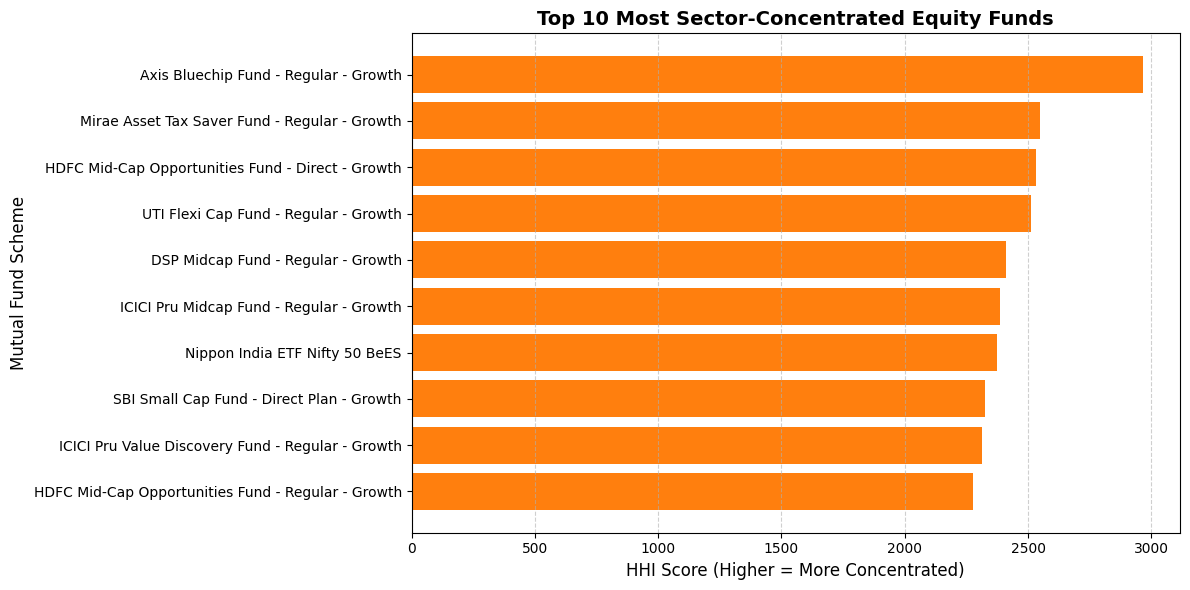

In [130]:
# 6. Plot the Chart (Top 10 Most Concentrated Funds)
top_10 = equity_hhi.head(10)

plt.figure(figsize=(12, 6))
# Horizontal bar chart so the long fund names fit nicely
plt.barh(top_10['scheme_name'], top_10['HHI_Score'], color='#ff7f0e')
plt.xlabel('HHI Score (Higher = More Concentrated)', fontsize=12)
plt.ylabel('Mutual Fund Scheme', fontsize=12)
plt.title('Top 10 Most Sector-Concentrated Equity Funds', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis() # Flips it so the #1 highest is at the very top
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save and Show
chart_path = '../reports/sector_hhi_chart.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
plt.show()

## Day 6: Advanced Analytics & Risk Metrics Summary

Based on the quantitative analysis and modeling performed on the Bluestock mutual fund dataset, here are the 5 key actionable insights:

**1. Tail Risk via VaR & CVaR (Task 1):**
Our Historical Value at Risk (95%) analysis reveals varying degrees of downside tail risk across the portfolio. For example, Fund AMFI **100033** carries the highest volatility with a 95% VaR of **-1.90%**, meaning in normal market conditions, we expect it to lose no more than that in a single day. However, its CVaR of **-2.35%** indicates that when extreme market events breach this threshold, the losses average significantly deeper, highlighting the need for conservative hedging. 

**2. Performance Consistency (Task 2):**
The Rolling 90-Day Sharpe Ratio analysis proves that point-in-time metrics are not enough to judge a fund. While Fund AMFI **100016** (Blue line) may have decent overall returns, its rolling Sharpe dropped severely below zero (hitting nearly -4.5) during mid-2022 and late-2024, indicating it took on uncompensated risk during market dips. Conversely, Fund AMFI **101206** (Red line) showed aggressive recent recovery, pushing its Sharpe above 7.0 in recent months.

**3. Investor Cohort Trends (Task 3):**
Cohort analysis by first-transaction year indicates shifting retail behavior. The **2024** cohort has committed a massive total invested amount of **₹3.49 Billion**, with an average SIP of **₹10,996**. Interestingly, the newer **2025** cohort shows a significantly higher average SIP commitment at **₹13,505**, shifting their top fund preference from AMFI 148568 to AMFI 119599. This suggests newer investors are entering with higher liquidity.

**4. SIP Continuity & Churn Risk (Task 4):**
By analyzing transaction date gaps for seasoned investors (6+ transactions), we built an 'At-Risk' churn model. We successfully flagged **1,332 investors** whose average payment gap has drifted past the healthy 30-day cycle into the danger zone (>35 days), with severe cases like INV000004 averaging 85.4 days between payments. Proactive RM (Relationship Manager) outreach to this specific list could save significant AUM from being lost to abandoned SIPs.

**5. Sector Concentration via HHI (Task 6):**
Using the Herfindahl-Hirschman Index (HHI) on portfolio holdings, we identified severe concentration risk in specific funds. The **Axis Bluechip Fund - Regular - Growth** scored the highest HHI (approaching 3000), heavily driven by its concentrated sector allocation strategy. While this drives high alpha during specific sector rallies, it poses an outsized systematic risk compared to well-diversified peers lower on the HHI index.